# Pulse amplitude optimisation with a Deep Neural Network

Reproduction of arXiv:2408.02376 in QuTiP-QIP, for the X and RX(pi/2) gates of fake_valencia.

A little warning: The original paper implements the H gate, but this is not a native gate to the Quantum Processor we use, the SCQubits() pre-implemented in Quitb. To try to reproduce their results, because the metric does not distingish the relative phase between states we implemented the RX(pi/2), which gives, from state |0> equal probabilities to measure |0> and |1>.

In [1]:
#To reload the code for changes every time a cell calling that code is run
%load_ext autoreload
%autoreload 2

#Packages needed for simulation
import numpy as np
import matplotlib.pyplot as plt
import os
import simulation_sq_gates as sim
import ml_model_sqgate as ml

#Make directory to save all results
os.makedirs('Results', exist_ok = True)

***Simulate the ampltiude-fidelity data***

The gates we implented need only one **sigma_x** control pulse in QuTiP to implement the desired gate. We implement the circuits of a single gate; $X$ and $RX (\pi/2)$ respectively and measure of the output state, compared with the thoeretical value, using the Bhattacharyya fidelity (see paper).

In [2]:
#Parameters of the simulation
gate = 'X'          #'X' or 'RX' 
use_drag = False     #If TRUE, it will not implement a single pulse, but will use also a sigma_y control
num_simulations = 400 #Number of amplitudes sampled in the paper
amp_max = 5.9 #Equivalence of Qiskit X gate calibrated pulse (pi rotation) is 0.168764, QuTiP is 1, so the equivalence is for [0,1] is [0,5.9]
num_trials = 1024 #Trials in the paper for each amplitude (QuTip gives back a probaility distribution for the final state, we sample to simulate noisy results)

data = sim.run_scan(gate = gate, num_simulations = num_simulations, amp_max = amp_max, 
            num_trials = num_trials, drag = use_drag, file_name = f'Results/amplitude_fidelity_{gate}.json')
print(data.shape)

(400, 2)


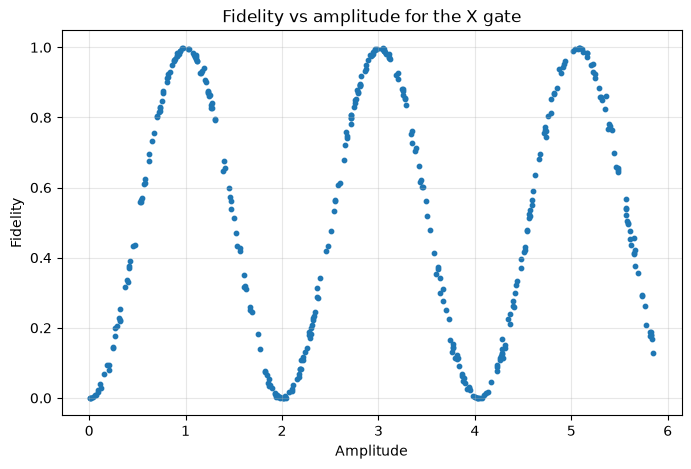

In [3]:
#Plot the simulated results for each gate
fig = plt.figure(figsize = (8, 5))
plt.scatter(data[:, 0], data[:, 1], s = 10)
plt.xlabel('Amplitude')
plt.ylabel('Fidelity')
plt.title(f'Fidelity vs amplitude for the {gate} gate')
plt.grid(True, alpha = 0.3)
fig.savefig(f'Results/AmpFid_data_{gate}.png', dpi = 200, bbox_inches = 'tight')

***Train the neural network on the simulated data***

We create a deep neural network which has as input the amplitude of the pulse that implements the gate and as output the fidelity with 4 inner layers. We combine the ReLU and Tanh activations functions, as well as a sigmoid in the outputlayer with image is $[0,1]$, just as the fidelity range. All is done in accordance to the indications given in the paper about the characterstics of the neural network 

Batch size 10: final test loss 0.00192
Batch size 20: final test loss 0.00134
Batch size 40: final test loss 0.00130


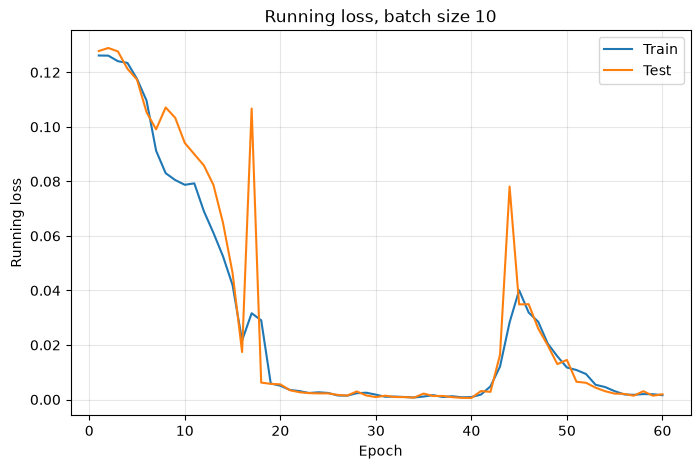

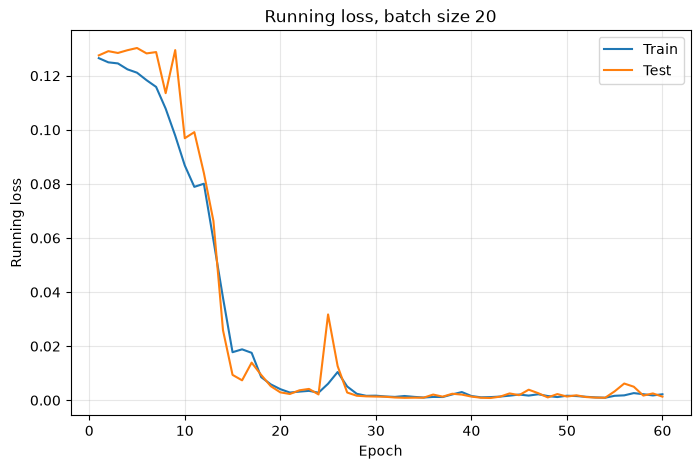

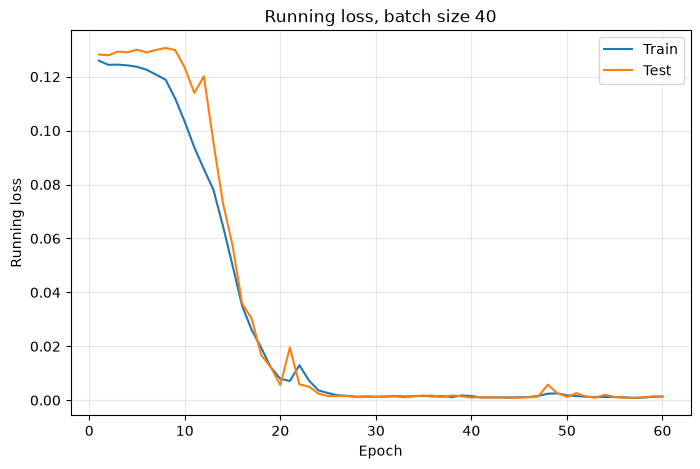

In [4]:
#Parameters of the neural network
batch_size = [10, 20, 40]
learning_rate = 0.001
epoch = 60

#Convert data into a torch tensor, reshape to match the network format and divide in training set and test set
train_dataset, test_dataset = ml.prepare_data(data)

models = {}
for size in batch_size:
    #Train the model for each batch size
    model, train_curve, test_curve = ml.train_model(train_dataset, test_dataset, batch_size = size, learning_rate = learning_rate, epoch = epoch)
    models[size] = model
    print(f'Batch size {size}: final test loss {test_curve[-1]:.5f}')

    #Plot both the test and the training loss
    fig = plt.figure(figsize = (8, 5))
    plt.plot(range(1, epoch+1), train_curve, label = 'Train')
    plt.plot(range(1, epoch+1), test_curve, label = 'Test')
    plt.xlabel('Epoch')
    plt.ylabel('Running loss')
    plt.title(f'Running loss, batch size {size}')
    plt.legend()
    plt.grid(True, alpha = 0.3)
    fig.savefig(f'Results/Loss_{gate}_{size}.png', dpi = 200, bbox_inches = 'tight')

***Two stage search for the amplitude that gives the highest fidelity***

Once the model is trained, we use it to map the space of amplitudes $[0,5.9]$ to their prediceted fidelity. TO zoom in, we implement, as it says in the paper a two stage process, with one coarse search and another finer one around the amplitude that reported the highest fidelity in the first one.

In [5]:
model = models[batch_size[-1]]
best_amp, coarse, fine = ml.find_best_amplitude(model, epsilon = 1e-3, amp_max = amp_max)
print(f'Amplitude of maximum predicted fidelity: {best_amp}')

Amplitude of maximum predicted fidelity: 5.10958143667528


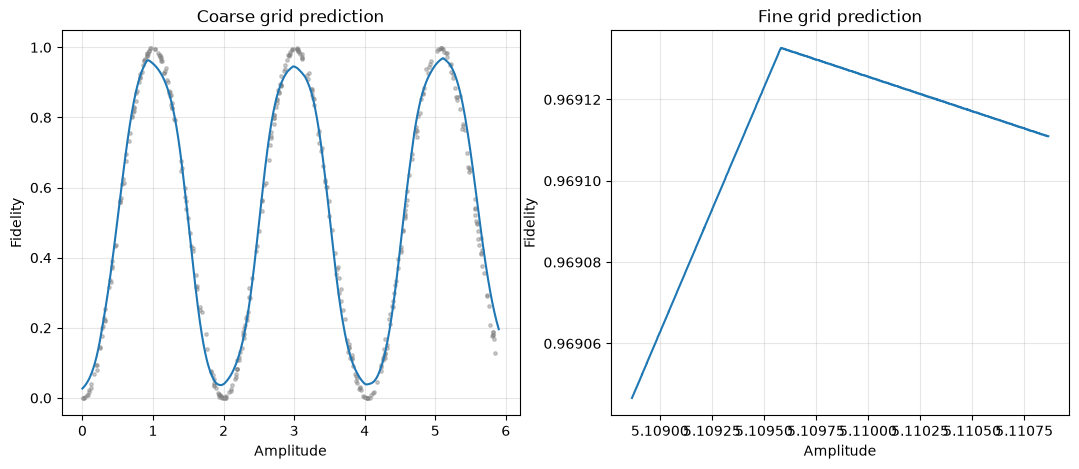

In [6]:
#Plot the coarse fidelity against the simulated data and the fine grid prediction
amp_c, fid_c = coarse
amp_f, fid_f = fine

fig, axes = plt.subplots(1, 2, figsize = (13, 5))
axes[0].scatter(data[:, 0], data[:, 1], s = 6, color = 'grey', alpha = 0.4)
axes[0].plot(amp_c, fid_c)
axes[0].set_xlabel('Amplitude')
axes[0].set_ylabel('Fidelity')
axes[0].set_title('Coarse grid prediction')
axes[0].grid(True, alpha = 0.3)

axes[1].plot(amp_f, fid_f)
axes[1].set_xlabel('Amplitude')
axes[1].set_ylabel('Fidelity')
axes[1].set_title('Fine grid prediction')
axes[1].grid(True, alpha = 0.3)
fig.savefig(f'Results/Prediction_{gate}.png', dpi = 200, bbox_inches = 'tight')

***Simulate the predicted amplitude***

We simulate the circuit to find the fidelity that corresponds to the best ampltiude according to the neural network

In [8]:
#Create the circuit
circuit = sim.create_circuit(gate)
processor, original_pulses = sim.build_processor(circuit, drag = use_drag)

#Run it 
fid = sim.simulate_amplitude(processor, original_pulses, best_amp, gate, num_trials)
print(f'Amplitude {best_amp:.6f}  simulated fidelity {fid:.6f}')

Amplitude 5.109581  simulated fidelity 0.994141
